In [1]:
import os
import numpy as np
import cv2    # opencv-python to be installed
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm

In [2]:
%%writefile kaggle.json
{
  "username": "shrutijain20878",
  "key": "KGAT_fd78f632b84f0d480513a3f0fd05852e"
}

Writing kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:15<00:00, 40.1MB/s]
100% 2.29G/2.29G [00:15<00:00, 162MB/s] 


In [5]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [6]:
data_path = "/content/chest_xray"

In [7]:
import os
# Defining the class name
class_name = ['NORMAL','PNEUMONIA']

# Creating a function to  get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    files_list = os.listdir(dir_name)
    return files_list
files_list_normal_train = get_list_of_files(data_path+'/train/'+class_name[0])
files_list_pneumonia_train = get_list_of_files(data_path+'/train/'+class_name[1])
files_list_normal_test = get_list_of_files(data_path+'/test/'+class_name[0])
files_list_pneumonia_test = get_list_of_files(data_path+'/test/'+class_name[1])
files_list_normal_val = get_list_of_files(data_path+'/val/'+class_name[0])
files_list_pneumonia_val = get_list_of_files(data_path+'/val/'+class_name[1])

In [8]:
print("Number of train samples in Normal category {}".format(len(files_list_normal_train)))
print("Number of train samples in Pneumonia category {}".format(len(files_list_pneumonia_train)))
print("Number of test samples in Normal category {}".format(len(files_list_normal_test)))
print("Number of test samples in Pneumonia category {}".format(len(files_list_pneumonia_test)))
print("Number of val samples in Normal category {}".format(len(files_list_normal_val)))
print("Number of val samples in Pneumonia category {}".format(len(files_list_pneumonia_val)))

Number of train samples in Normal category 1341
Number of train samples in Pneumonia category 3875
Number of test samples in Normal category 234
Number of test samples in Pneumonia category 390
Number of val samples in Normal category 8
Number of val samples in Pneumonia category 8


In [27]:
# For ResNet
resnet_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

resnet_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# For Inception
inception_train_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

inception_test_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

(1708, 1944)


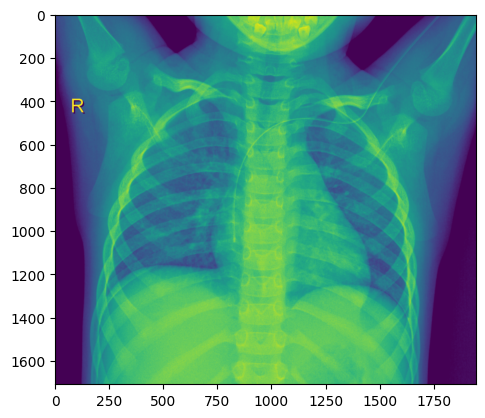

In [10]:
#Exploring the images
rand_img_no = np.random.randint(0,len(files_list_normal_train))
img = data_path + '/train/NORMAL/'+ files_list_normal_train[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(1133, 1508)


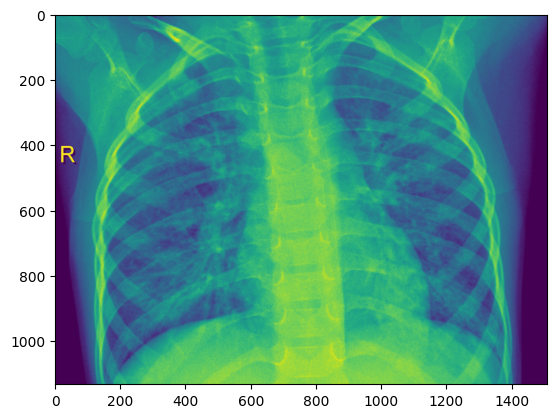

In [11]:
img = data_path + '/train/PNEUMONIA/'+ files_list_pneumonia_train[np.random.randint(0,len(files_list_pneumonia_train))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(1461, 2006)


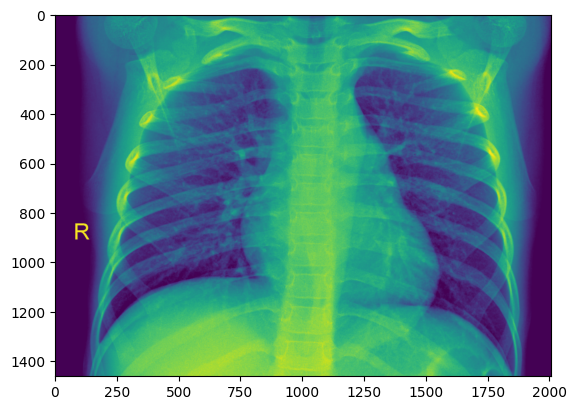

In [12]:
rand_img_no = np.random.randint(0,len(files_list_normal_test))
img = data_path + '/test/NORMAL/'+ files_list_normal_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(776, 1000)


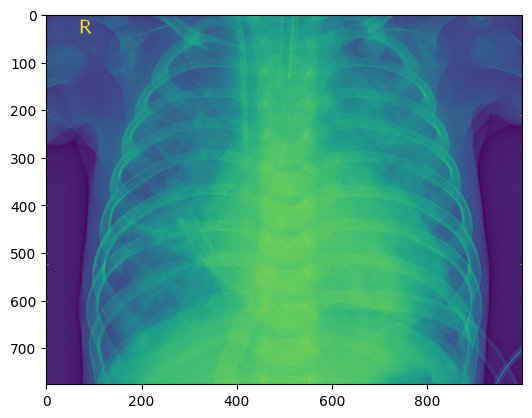

In [13]:
img = data_path + '/test/PNEUMONIA/'+ files_list_pneumonia_test[np.random.randint(0,len(files_list_pneumonia_test))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

In [28]:
# Creating data loaders
train_resnet = datasets.ImageFolder(
    os.path.join(data_path, "train"),
    transform=resnet_train_transform
)

val_resnet = datasets.ImageFolder(
    os.path.join(data_path, "val"),
    transform=resnet_test_transform
)

test_resnet = datasets.ImageFolder(
    os.path.join(data_path, "test"),
    transform=resnet_test_transform
)
# Resnet-224x224
#inception 229x229

train_inception = datasets.ImageFolder(
    os.path.join(data_path, "train"),
    transform=inception_train_transform
)

val_inception = datasets.ImageFolder(
    os.path.join(data_path, "val"),
    transform=inception_test_transform
)

test_inception = datasets.ImageFolder(
    os.path.join(data_path, "test"),
    transform=inception_test_transform
)

In [29]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

targets = [label for _, label in train_resnet.samples]

class_counts = np.bincount(targets)
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [30]:
train_loader_resnet = DataLoader(
    train_resnet,
    batch_size=32,
    sampler=sampler,
    pin_memory=True
)

val_loader_resnet = DataLoader(
    val_resnet,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

test_loader_resnet = DataLoader(
    test_resnet,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)



train_loader_inception = DataLoader(
    train_inception,
    batch_size=32,
    sampler=sampler,
    pin_memory=True
)

val_loader_inception = DataLoader(
    val_inception,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

test_loader_inception = DataLoader(
    test_inception,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)


In [31]:
print("Classes:", train_resnet.classes)
print("Train size:", len(train_resnet))
print("Val size:", len(val_resnet))
print("Test size:", len(test_resnet))

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Val size: 16
Test size: 624


In [32]:
from collections import Counter

images, labels = next(iter(train_loader_resnet))
print("Train batch distribution:", Counter(labels.tolist()))

Train batch distribution: Counter({1: 17, 0: 15})


In [33]:
# checking balancing on entire epochs
from collections import Counter

epoch_labels = []

for _, labels in train_loader_resnet:
    epoch_labels.extend(labels.tolist())

print("Epoch distribution:", Counter(epoch_labels))

Epoch distribution: Counter({0: 2631, 1: 2585})


In [40]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [41]:
from torchvision import models
import torch.nn as nn

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)   # Binary output
)

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.7MB/s]


In [42]:
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1,
    aux_logits=True
)

# Freeze backbone
for param in inception.parameters():
    param.requires_grad = False

# Replace classifiers
inception.fc = nn.Linear(inception.fc.in_features, 1)
inception.AuxLogits.fc = nn.Linear(inception.AuxLogits.fc.in_features, 1)

inception = inception.to(device)


In [43]:
criterion = nn.BCEWithLogitsLoss()

In [44]:
optimizer_resnet = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

optimizer_inception = torch.optim.Adam(
    list(inception.fc.parameters()) +
    list(inception.AuxLogits.fc.parameters()),
    lr=1e-3
)

In [45]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable params ResNet:", count_trainable_params(resnet))
print("Trainable params Inception:", count_trainable_params(inception))

Trainable params ResNet: 524801
Trainable params Inception: 2818


In [46]:
for name, param in resnet.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

In [47]:
for name, param in inception.named_parameters():
    if "Mixed_7" in name or "Mixed_6" in name:
        param.requires_grad = True

In [48]:
optimizer_resnet = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

optimizer_inception = torch.optim.Adam(
    filter(lambda p: p.requires_grad, inception.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [49]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler_resnet = ReduceLROnPlateau(
    optimizer_resnet, mode="max", factor=0.5, patience=2
)

scheduler_inception = ReduceLROnPlateau(
    optimizer_inception, mode="max", factor=0.5, patience=2
)

In [50]:
from tqdm import tqdm

def train_one_epoch_resnet(model, loader, optimizer):
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(device)
        labels = labels.float().to(device).view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images).view(-1, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [51]:
def train_one_epoch_inception(model, loader, optimizer):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().view(-1, 1).to(device)

        optimizer.zero_grad()

        outputs, aux_outputs = model(images)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)

        loss = loss1 + 0.4 * loss2
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [52]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix

def evaluate(model, loader):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = torch.sigmoid(model(images).view(-1, 1))

            y_true.extend(labels.numpy())
            y_prob.extend(outputs.cpu().numpy())

    y_pred = (np.array(y_prob) > 0.5).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    recall = recall_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)

    return auc, recall, sensitivity

In [53]:
fine_tune_epochs = 5

for epoch in range(fine_tune_epochs):
    print(f"\nFine-Tuning Epoch {epoch+1}/{fine_tune_epochs}")

    # ResNet
    loss_r = train_one_epoch_resnet(resnet, train_loader_resnet, optimizer_resnet)
    auc_r, rec_r, sen_r = evaluate(resnet, val_loader_resnet)
    scheduler_resnet.step(auc_r)

    # Inception
    loss_i = train_one_epoch_inception(
        inception, train_loader_inception, optimizer_inception
    )
    auc_i, rec_i, sen_i = evaluate(inception, val_loader_inception)
    scheduler_inception.step(auc_i)

    print(f"ResNet   → Loss:{loss_r:.4f} AUC:{auc_r:.3f} Recall:{rec_r:.3f} Sens:{sen_r:.3f}")
    print(f"Incept.  → Loss:{loss_i:.4f} AUC:{auc_i:.3f} Recall:{rec_i:.3f} Sens:{sen_i:.3f}")



Fine-Tuning Epoch 1/5


Training: 100%|██████████| 163/163 [02:23<00:00,  1.14it/s]


ResNet   → Loss:0.1705 AUC:1.000 Recall:1.000 Sens:1.000
Incept.  → Loss:0.1614 AUC:1.000 Recall:1.000 Sens:1.000

Fine-Tuning Epoch 2/5


Training: 100%|██████████| 163/163 [02:21<00:00,  1.15it/s]


ResNet   → Loss:0.0440 AUC:1.000 Recall:1.000 Sens:1.000
Incept.  → Loss:0.0561 AUC:1.000 Recall:1.000 Sens:1.000

Fine-Tuning Epoch 3/5


...

ResNet   → Loss:0.0302 AUC:1.000 Recall:1.000 Sens:1.000
Incept.  → Loss:0.0409 AUC:1.000 Recall:1.000 Sens:1.000

Fine-Tuning Epoch 4/5


Training: 100%|██████████| 163/163 [02:21<00:00,  1.15it/s]


ResNet   → Loss:0.0224 AUC:1.000 Recall:1.000 Sens:1.000
Incept.  → Loss:0.0208 AUC:1.000 Recall:1.000 Sens:1.000

Fine-Tuning Epoch 5/5


Training: 100%|██████████| 163/163 [02:21<00:00,  1.15it/s]


ResNet   → Loss:0.0106 AUC:1.000 Recall:1.000 Sens:1.000
Incept.  → Loss:0.0117 AUC:1.000 Recall:1.000 Sens:1.000


In [54]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_test(model, loader):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.numpy()

            outputs = torch.sigmoid(model(images).view(-1))
            y_prob.extend(outputs.cpu().numpy())
            y_true.extend(labels)

    y_pred = (np.array(y_prob) > 0.5).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    recall = recall_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return auc, recall, sensitivity, specificity, y_true, y_prob

In [55]:
auc_r, rec_r, sen_r, spec_r, y_true_r, y_prob_r = evaluate_test(
    resnet, test_loader_resnet
)

print(f"ResNet TEST → AUC:{auc_r:.3f} Recall:{rec_r:.3f} Sens:{sen_r:.3f} Spec:{spec_r:.3f}")

ResNet TEST → AUC:0.955 Recall:0.997 Sens:0.997 Spec:0.590


In [56]:
auc_i, rec_i, sen_i, spec_i, y_true_i, y_prob_i = evaluate_test(
    inception, test_loader_inception
)

print(f"Inception TEST → AUC:{auc_i:.3f} Recall:{rec_i:.3f} Sens:{sen_i:.3f} Spec:{spec_i:.3f}")

Inception TEST → AUC:0.950 Recall:0.995 Sens:0.995 Spec:0.543


In [57]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

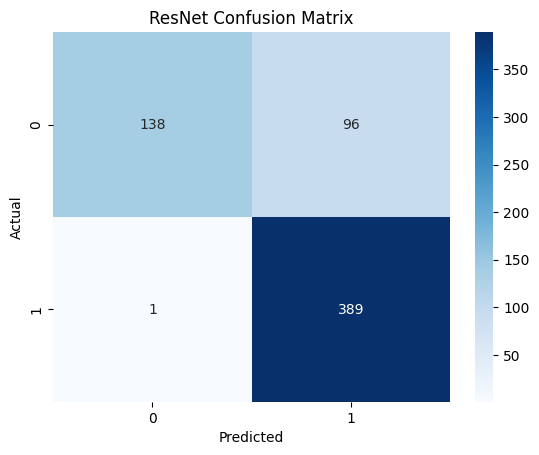

In [58]:
plot_confusion(y_true_r, (np.array(y_prob_r) > 0.5).astype(int),
               "ResNet Confusion Matrix")

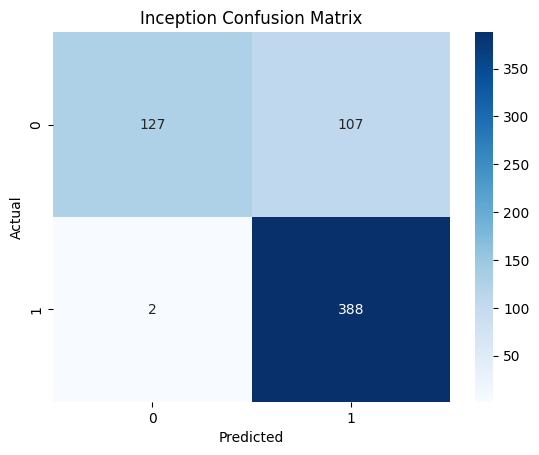

In [59]:
plot_confusion(y_true_i, (np.array(y_prob_i) > 0.5).astype(int),
               "Inception Confusion Matrix")

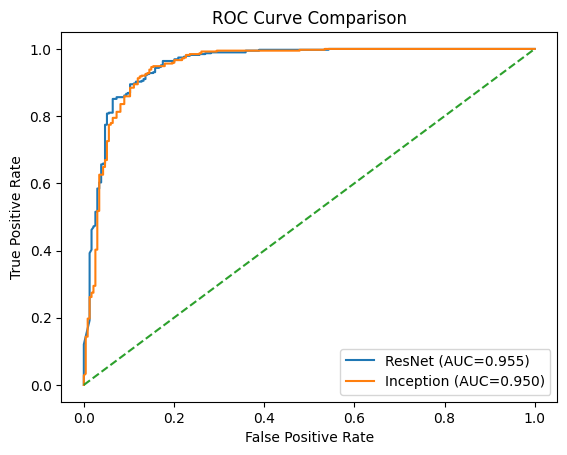

In [60]:
fpr_r, tpr_r, _ = roc_curve(y_true_r, y_prob_r)
fpr_i, tpr_i, _ = roc_curve(y_true_i, y_prob_i)

plt.plot(fpr_r, tpr_r, label=f"ResNet (AUC={auc_r:.3f})")
plt.plot(fpr_i, tpr_i, label=f"Inception (AUC={auc_i:.3f})")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [61]:
import torch
import os

os.makedirs("saved_models", exist_ok=True)

torch.save(resnet.state_dict(), "saved_models/resnet_pneumonia.pth")
torch.save(inception.state_dict(), "saved_models/inception_pneumonia.pth")

print("Models saved successfully")

Models saved successfully
